# Histogramas y Boxplots: Distribuciones de Divorcios y VIF
Este cuaderno analiza las distribuciones estadísticas de divorcios y violencia intrafamiliar.

In [1]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != 'MD_Proyecto1':
    for parent in PROJECT_ROOT.parents:
        if parent.name == 'MD_Proyecto1':
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import data_pipeline as dp
dp = importlib.reload(dp)

panel = dp.build_panel(force_rebuild=False, only_common_years=False).dropna(subset=['departamento', 'anio']).copy()
panel[['divorcios_total', 'vif_total']] = panel[['divorcios_total', 'vif_total']].fillna(0)
print(f"Panel cargado: {len(panel)} registros")

sns.set_style('whitegrid')

Panel cargado: 351 registros


## 1. Distribución de Divorcios
Exploramos la distribución de casos de divorcios.

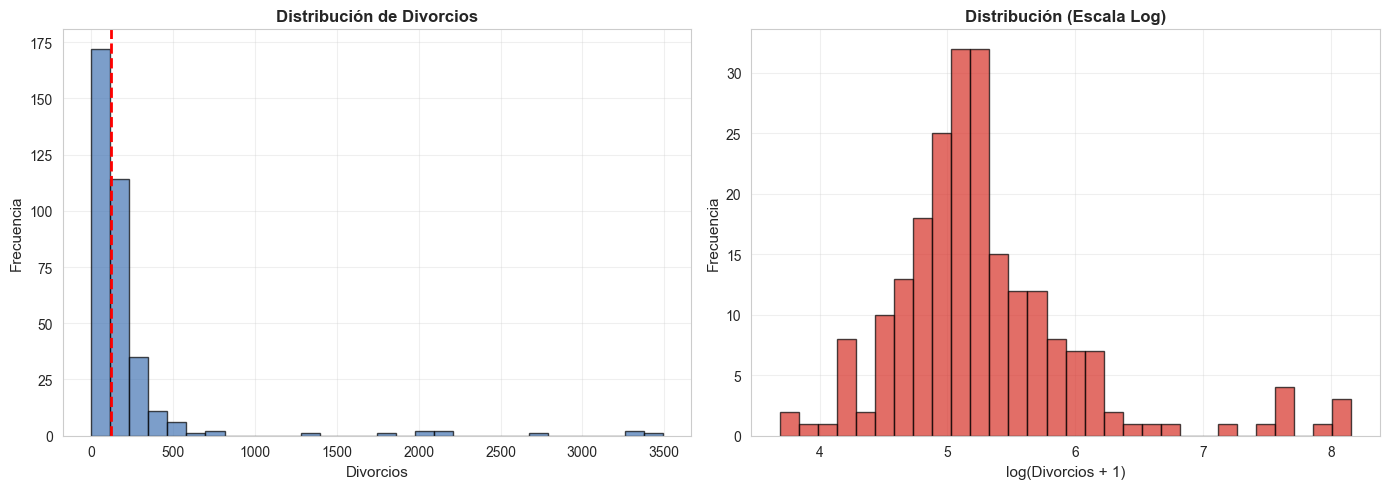

Media: 189.2
Mediana: 119.0


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(panel['divorcios_total'], bins=30, color='#4575b4', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Divorcios', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución de Divorcios', fontsize=12, fontweight='bold')
axes[0].axvline(panel['divorcios_total'].median(), color='red', linestyle='--', linewidth=2)
axes[0].grid(True, alpha=0.3)

divorcios_positivos = panel[panel['divorcios_total'] > 0]['divorcios_total']
axes[1].hist(np.log1p(divorcios_positivos), bins=30, color='#d73027', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('log(Divorcios + 1)', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('Distribución (Escala Log)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Media: {panel['divorcios_total'].mean():.1f}")
print(f"Mediana: {panel['divorcios_total'].median():.1f}")

**Conclusión**: La distribución está altamente sesgada hacia la derecha.
Pocos departamentos concentran la mayoría de divorcios.

## 2. Boxplots de Divorcios y VIF
Comparamos las distribuciones y detectamos valores atípicos.

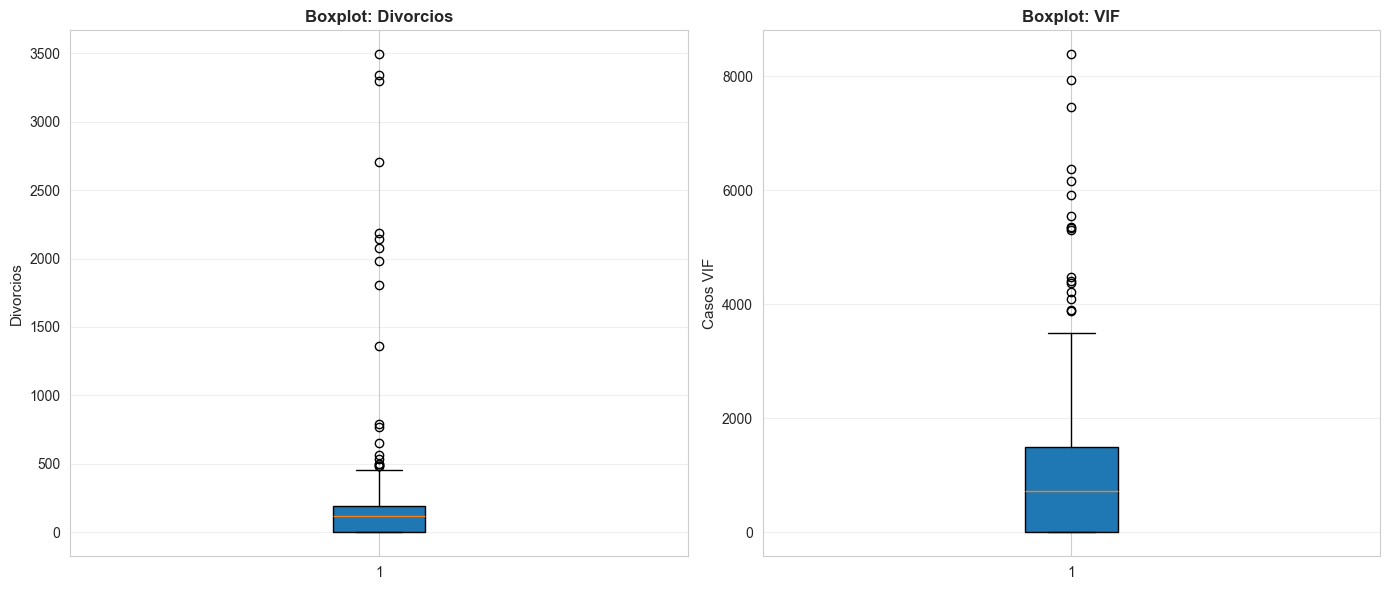

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bp1 = axes[0].boxplot(panel['divorcios_total'], vert=True, patch_artist=True)
axes[0].set_ylabel('Divorcios', fontsize=11)
axes[0].set_title('Boxplot: Divorcios', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

bp2 = axes[1].boxplot(panel['vif_total'], vert=True, patch_artist=True)
axes[1].set_ylabel('Casos VIF', fontsize=11)
axes[1].set_title('Boxplot: VIF', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Conclusión**: Los boxplots revelan valores atípicos correspondientes principalmente
al departamento de Guatemala. Esta asimetría es esperada.

## 3. Distribución por Tipo de Violencia
Analizamos las distribuciones de los tipos de violencia.

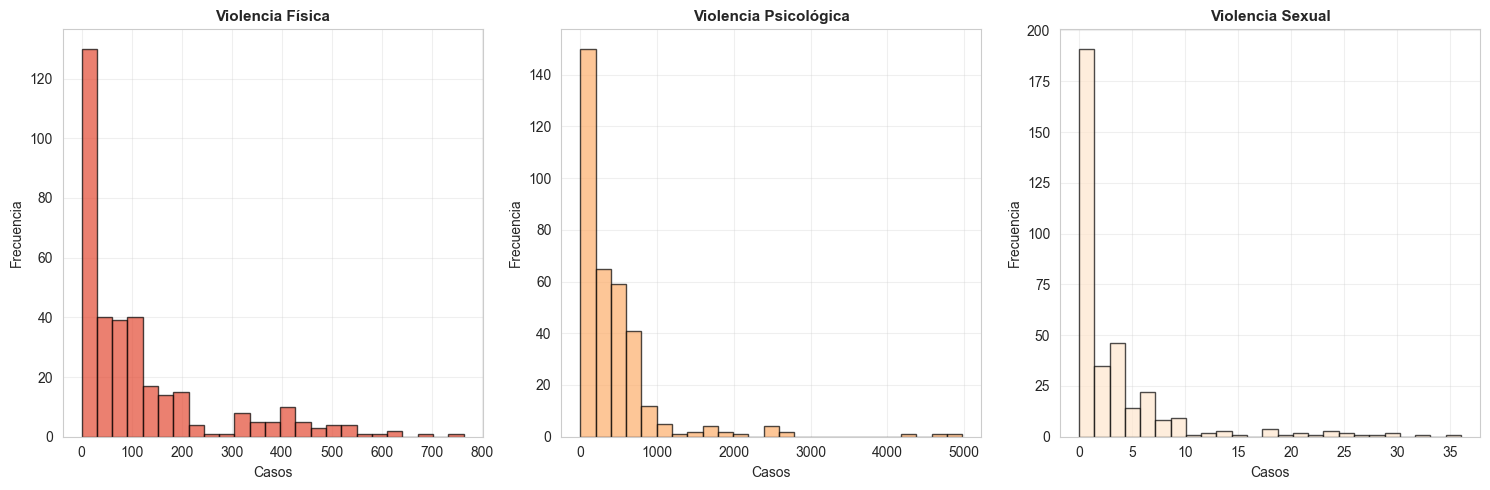

In [4]:
tipos_vif = ['vif_tipo_fisica', 'vif_tipo_psicologica', 'vif_tipo_sexual']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colores = ['#e34a33', '#fdae6b', '#fee6ce']
nombres = ['Violencia Física', 'Violencia Psicológica', 'Violencia Sexual']

for i, (col, color, nombre) in enumerate(zip(tipos_vif, colores, nombres)):
    axes[i].hist(panel[col], bins=25, color=color, alpha=0.7, edgecolor='black')
    axes[i].set_xlabel('Casos', fontsize=10)
    axes[i].set_ylabel('Frecuencia', fontsize=10)
    axes[i].set_title(nombre, fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Conclusión**: La violencia física es el tipo más común, seguida de la psicológica.
La violencia sexual podría estar subregistrada.